# Multiple Testing Correction

## Overview

When testing m hypotheses simultaneously at α=0.05, the probability of at least one false positive is 1−(1−0.05)^m. With m=20 tests, this exceeds 64%. Multiple testing corrections control either the **family-wise error rate (FWER)** or the **false discovery rate (FDR)**.

**FWER vs. FDR:**

| | Controls | Appropriate when | Conservative? |
|---|---|---|---|
| **Bonferroni** | FWER: P(any false positive) | Any false positive is costly; m small | Most conservative |
| **Holm** | FWER (stepdown) | Same as Bonferroni; uniformly more powerful | Less conservative than Bonferroni |
| **Benjamini-Hochberg** | FDR: expected proportion of false discoveries | Exploratory; some false positives tolerable; m large | Least conservative |
| **Benjamini-Yekutieli** | FDR under dependence | Tests are correlated | More conservative than B-H |

**When no correction is needed:**
- Pre-specified single primary outcome (the other tests are exploratory)
- Replication across independent datasets
- Mechanistically related tests where the family of comparisons is conceptually one question

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(patchwork)

set.seed(42)

# ── Simulate: 50 species tested for differential abundance ───────────────────
# 8 truly different; 42 are null (no real effect)
m       <- 50
n_true  <- 8
n_null  <- m - n_true

# True effects: larger mean difference
true_pvals <- map_dbl(1:n_true, ~t.test(
  rnorm(30, mean=2.5, sd=3),
  rnorm(30, mean=0,   sd=3)
)$p.value)

# Null effects: no difference → p-values uniform under H0
null_pvals <- map_dbl(1:n_null, ~t.test(
  rnorm(30, mean=0, sd=3),
  rnorm(30, mean=0, sd=3)
)$p.value)

results <- tibble(
  species   = paste0("sp", 1:m),
  raw_p     = c(true_pvals, null_pvals),
  truly_sig = c(rep(TRUE, n_true), rep(FALSE, n_null))
) %>% arrange(raw_p)

cat(sprintf("m=%d tests | %d true positives | %d nulls\n",
            m, n_true, n_null))
cat(sprintf("Naive: %d significant at α=0.05 (includes ~%.0f false positives)\n",
            sum(results$raw_p < 0.05),
            sum(!results$truly_sig & results$raw_p < 0.05)))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'patchwork' was built under R version 4.4.3"


m=50 tests | 8 true positives | 42 nulls
Naive: 12 significant at α=0.05 (includes ~4 false positives)


---

## Applying Corrections

In [2]:
results <- results %>%
  mutate(
    p_bonferroni = p.adjust(raw_p, method="bonferroni"),
    p_holm       = p.adjust(raw_p, method="holm"),
    p_BH         = p.adjust(raw_p, method="BH"),    # Benjamini-Hochberg FDR
    p_BY         = p.adjust(raw_p, method="BY")     # Benjamini-Yekutieli
  )

# Summary: how many discoveries at α=0.05 after correction?
discovery_summary <- tibble(
  method      = c("None","Bonferroni","Holm","BH (FDR)","BY (FDR)"),
  discoveries = c(
    sum(results$raw_p     < 0.05),
    sum(results$p_bonferroni < 0.05),
    sum(results$p_holm    < 0.05),
    sum(results$p_BH      < 0.05),
    sum(results$p_BY      < 0.05)
  ),
  false_positives = c(
    sum(!results$truly_sig & results$raw_p     < 0.05),
    sum(!results$truly_sig & results$p_bonferroni < 0.05),
    sum(!results$truly_sig & results$p_holm    < 0.05),
    sum(!results$truly_sig & results$p_BH      < 0.05),
    sum(!results$truly_sig & results$p_BY      < 0.05)
  )
) %>%
  mutate(true_positives = discoveries - false_positives,
         missed         = n_true - true_positives)

print(discovery_summary)

# A tibble: 5 × 5
  method     discoveries false_positives true_positives missed
  <chr>            <int>           <int>          <int>  <dbl>
1 None                12               4              8      0
2 Bonferroni           3               0              3      5
3 Holm                 3               0              3      5
4 BH (FDR)             9               3              6      2
5 BY (FDR)             3               0              3      5


---

## Visualising: p-Value Histogram and Correction Comparison

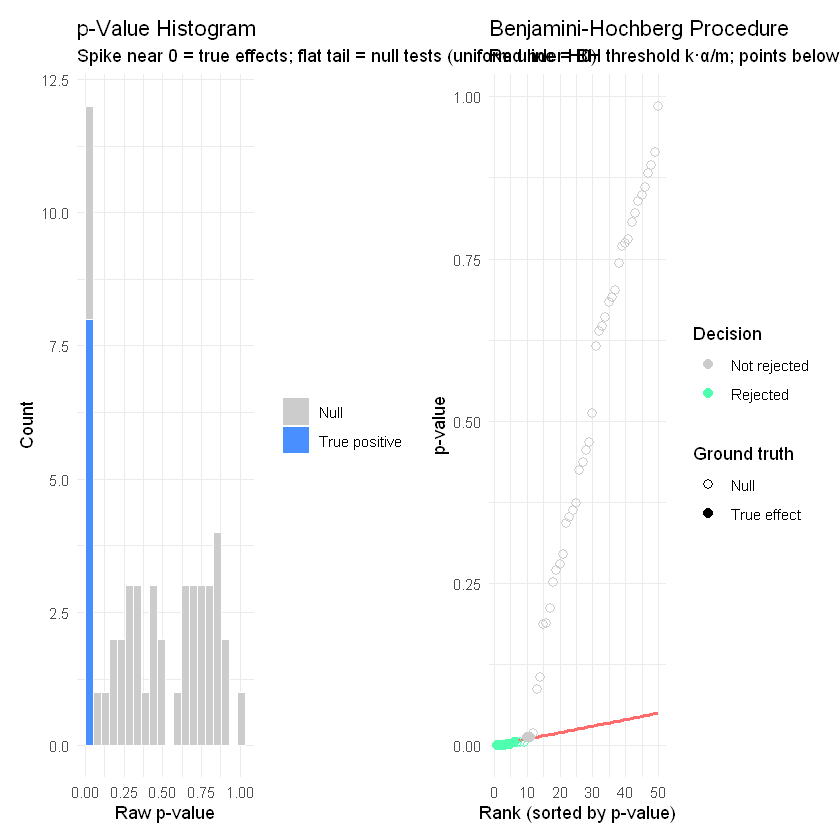

In [5]:
# ── p-Value histogram: diagnostic ─────────────────────────────────────────────
p_hist <- ggplot(results, aes(x = raw_p, fill = truly_sig)) +
  geom_histogram(bins = 20, boundary = 0, color = "white", linewidth = 0.3) +
  scale_fill_manual(values = c("TRUE" = "#4a8fff", "FALSE" = "#cccccc"),
                    labels = c("TRUE" = "True positive", "FALSE" = "Null")) +
  labs(title    = "p-Value Histogram",
       subtitle = "Spike near 0 = true effects; flat tail = null tests (uniform under H0)",
       x = "Raw p-value", y = "Count", fill = NULL) +
  theme_minimal()

# ── BH procedure: step-by-step visualisation ─────────────────────────────────
bh_df <- results %>%
  arrange(raw_p) %>%
  mutate(
    rank      = row_number(),
    bh_thresh = rank / m * 0.05,
    rejected  = raw_p <= bh_thresh
  )

p_bh <- ggplot(bh_df, aes(x = rank, y = raw_p, color = rejected, shape = truly_sig)) +
  geom_line(aes(x = rank, y = bh_thresh),   # x must be explicit when inherit.aes = FALSE
            color = "#ff6b6b", linewidth = 1,
            inherit.aes = FALSE, data = bh_df) +
  geom_point(size = 2.5) +
  scale_color_manual(values = c("TRUE" = "#4fffb0", "FALSE" = "#cccccc"),
                     labels = c("TRUE" = "Rejected", "FALSE" = "Not rejected")) +
  scale_shape_manual(values = c("TRUE" = 16, "FALSE" = 1),
                     labels = c("TRUE" = "True effect", "FALSE" = "Null")) +
  labs(title    = "Benjamini-Hochberg Procedure",
       subtitle = "Red line = BH threshold k·α/m; points below line are rejected",
       x = "Rank (sorted by p-value)", y = "p-value",
       color = "Decision", shape = "Ground truth") +
  theme_minimal()

(p_hist | p_bh)

---

## FDR vs. FWER: Empirical Comparison Across Simulations

In [6]:
# Simulate 1000 experiments; measure actual FWER and FDR achieved
simulate_testing <- function(m=50, n_true=8, n_per=30, nsim=500) {
  map_dfr(1:nsim, function(sim) {
    p_true <- map_dbl(1:n_true,  ~t.test(rnorm(n_per,2,3),rnorm(n_per,0,3))$p.value)
    p_null <- map_dbl(1:(m-n_true), ~t.test(rnorm(n_per,0,3),rnorm(n_per,0,3))$p.value)
    ps     <- c(p_true, p_null)
    sig    <- c(rep(TRUE,n_true), rep(FALSE,m-n_true))

    p_bon <- p.adjust(ps, "bonferroni")
    p_bh  <- p.adjust(ps, "BH")

    tibble(
      method       = c("Bonferroni","BH (FDR)"),
      any_fp       = c(any(!sig & p_bon<0.05), any(!sig & p_bh<0.05)),
      fdr          = c(sum(!sig & p_bon<0.05)/max(sum(p_bon<0.05),1),
                       sum(!sig & p_bh<0.05)/max(sum(p_bh<0.05),1)),
      power        = c(mean(sig[p_bon<0.05]), mean(sig[p_bh<0.05]))
    )
  })
}

sim_results <- simulate_testing(nsim=300)

sim_results %>%
  group_by(method) %>%
  summarise(
    FWER        = round(mean(any_fp), 3),
    mean_FDR    = round(mean(fdr),    3),
    mean_power  = round(mean(power, na.rm=TRUE), 3)
  ) %>%
  print()
# BH: lower power cost than Bonferroni; controls FDR ≤ 0.05; FWER may exceed 0.05
# Bonferroni: guaranteed FWER ≤ 0.05; fewer true discoveries

# A tibble: 2 × 4
  method      FWER mean_FDR mean_power
  <chr>      <dbl>    <dbl>      <dbl>
1 BH (FDR)    0.16    0.041      0.954
2 Bonferroni  0.05    0.021      0.975


---

## Common Pitfalls

**1. Applying Bonferroni correction to all tests regardless of context**  
Bonferroni controls the probability of any false positive across the entire family. If each test is a separate scientific question (different species, different outcomes, different studies), they are not a family and no correction is needed. Only tests that collectively form a single inferential claim require family-wise correction.

**2. Confusing FDR control with FWER control**  
Benjamini-Hochberg controls the expected proportion of false positives among all discoveries — not the probability of any false positive. With BH at q=0.05, you expect 5% of your significant results to be false positives. This is appropriate for exploratory screening; it is not appropriate when any single false positive has serious consequences.

**3. Applying the correction to exploratory tests while reporting them as confirmatory**  
Running 50 tests, applying BH correction, and reporting the 12 significant ones as confirmed findings is circular — BH controls the FDR in expectation, not per-experiment. Significant results from corrected exploratory analyses require independent replication before being treated as confirmed.

**4. Not inspecting the p-value histogram before applying correction**  
The shape of the p-value histogram is informative: a uniform distribution with a spike near zero indicates true effects exist; a non-uniform distribution across the bulk suggests model misspecification or test violations. Anti-conservative tests (spike near 1) indicate inflation. Always plot the raw p-value histogram before applying any correction.

**5. Using Bonferroni when tests are positively correlated**  
Bonferroni assumes independence (or uses a worst-case bound). When tests are positively correlated — as they typically are in ecological data where species co-occur — Bonferroni over-corrects. Holm is uniformly more powerful than Bonferroni at the same FWER level. For strongly correlated tests, consider permutation-based corrections that account for the actual dependence structure.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*